<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Chapter_8_Image_Features_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Automating the Featurizer -- Image Feature Extraction and Deep Learning

This notebook explores how machines "see" images -- from the simplest (and worst) approaches through carefully engineered feature extractors like **SIFT** and **HOG**, to the modern revolution of **deep neural networks** that learn features automatically.

The core insight of this chapter: **individual pixels are terrible features**. What matters are *relationships* between pixels -- edges, textures, shapes. The history of computer vision is the story of increasingly sophisticated ways to capture these relationships.

We cover:
1. **Why simple features fail** -- color profiles and raw pixel distances
2. **Image gradients** -- the first useful building block
3. **Gradient orientation histograms** -- SIFT and HOG feature extraction
4. **Deep learning layers** -- fully connected, convolutional, ReLU, pooling, normalization
5. **AlexNet architecture** -- how it all comes together

---
**Key idea:** Text analysis succeeded earlier than image analysis because a "word" carries rich semantic meaning, while a single pixel carries almost none. Feature extraction bridges this gap.

In [ ]:
# ============================================================
# Setup
# ============================================================
# On Google Colab, uncomment if needed:
# !pip install -q scikit-image

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from skimage import data, color, feature
from scipy import signal, ndimage
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")
print(f"NumPy version: {np.__version__}")

All imports successful.
NumPy version: 2.0.2


We use `scikit-image` for the built-in test images and image processing utilities, and `scipy.signal` for convolution operations. All the heavy image processing in this chapter is done from scratch with NumPy to build intuition.

---
# The Simplest Image Features (and Why They Don't Work)

Before building sophisticated features, let us understand *why* naive approaches fail. Consider two tasks:

**Task 1: Color histograms.** Two images can have identical color distributions yet depict completely different things (a blue sky with white clouds vs. the Greek flag). Color alone discards all *spatial* information.

**Task 2: Raw pixel distances.** Resize images to the same dimensions, flatten each into a long vector, and measure Euclidean distance. This is too strict -- a cloud shifted 10 pixels to the right is still a cloud, but its pixel vector changes dramatically.

$$d(\mathbf{I}_1, \mathbf{I}_2) = \sqrt{\sum_{i,j} (I_1(i,j) - I_2(i,j))^2}$$

The problem is fundamental: **individual pixels carry almost no semantic information**. They are bad atomic units for analysis. We need features that capture *structure* -- relationships between neighboring pixels.

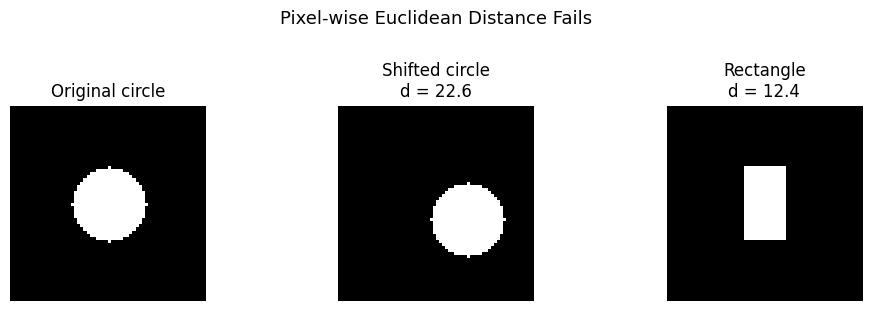

In [ ]:
# Demonstration: why raw pixel distance fails
# Create a simple white circle on black background, then shift it
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# Original circle
img1 = np.zeros((64, 64))
y, x = np.ogrid[-32:32, -32:32]
mask = x**2 + y**2 <= 12**2
img1[mask] = 1.0

# Shifted circle (same object, different position)
img2 = np.zeros((64, 64))
mask_shifted = (x - 10)**2 + (y - 5)**2 <= 12**2
img2[mask_shifted] = 1.0

# Different object (rectangle) at original position
img3 = np.zeros((64, 64))
img3[20:44, 25:39] = 1.0

# Compute pixel distances
d_shift = np.sqrt(np.sum((img1 - img2)**2))
d_diff = np.sqrt(np.sum((img1 - img3)**2))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Original circle')
axes[0].axis('off')
axes[1].imshow(img2, cmap='gray')
axes[1].set_title(f'Shifted circle\nd = {d_shift:.1f}')
axes[1].axis('off')
axes[2].imshow(img3, cmap='gray')
axes[2].set_title(f'Rectangle\nd = {d_diff:.1f}')
axes[2].axis('off')
plt.suptitle('Pixel-wise Euclidean Distance Fails', fontsize=13, y=1.02)
plt.tight_layout()

**Figure: The failure of pixel distance.** The original circle and the shifted circle are the *same object*, yet their pixel distance is large because every pixel has moved. Meanwhile, the rectangle (a completely different shape) might have a comparable or smaller distance. Pixel distance penalizes *translation* as harshly as *deformation* -- clearly wrong for any meaningful notion of image similarity.

This motivates the search for **transformation-invariant features** that describe *what* is in an image, not *where* each pixel sits.

---
# Image Gradients: The First Useful Building Block

To do better than raw pixels, we compute **differences between neighboring pixels**. These differences -- called **image gradients** -- are large at object boundaries, shadows, textures, and patterns. They capture *local structure*.

## Computing the Gradient

The gradient at pixel $(i, j)$ is a 2D vector composed of horizontal and vertical differences:

$$g_x(i,j) = I(i+1, j) - I(i-1, j) \qquad g_y(i,j) = I(i, j+1) - I(i, j-1)$$

Together they form the gradient vector:

$$\nabla I(i,j) = \begin{pmatrix} g_x(i,j) \\ g_y(i,j) \end{pmatrix}$$

This vector has two key properties:
- **Magnitude** $= \sqrt{g_x^2 + g_y^2}$ -- *how much* the image changes (strong at edges)
- **Orientation** $\theta = \arctan\left(\frac{g_y}{g_x}\right)$ -- *in what direction* the change occurs

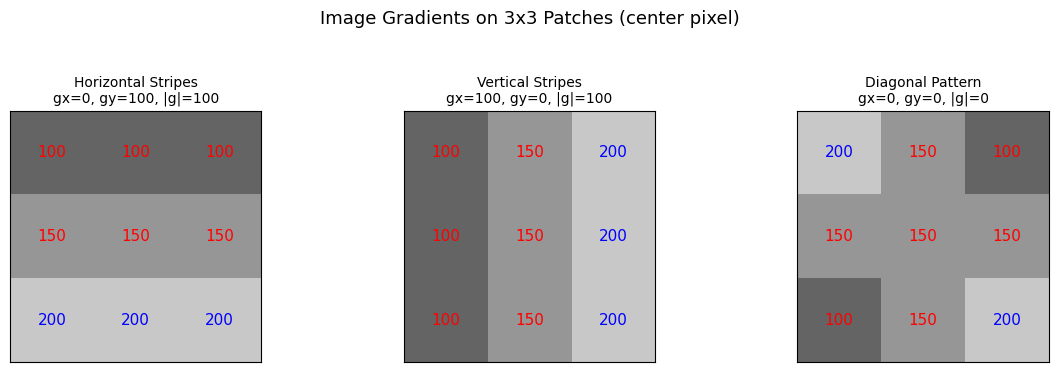

In [ ]:
# Toy examples: gradients on 3x3 pixel patches
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Example 1: Horizontal stripes (gradient is vertical)
patch1 = np.array([[100, 100, 100],
                   [150, 150, 150],
                   [200, 200, 200]])

# Example 2: Vertical stripes (gradient is horizontal)
patch2 = np.array([[100, 150, 200],
                   [100, 150, 200],
                   [100, 150, 200]])

# Example 3: Diagonal pattern
patch3 = np.array([[200, 150, 100],
                   [150, 150, 150],
                   [100, 150, 200]])

patches = [patch1, patch2, patch3]
titles = ['Horizontal Stripes', 'Vertical Stripes', 'Diagonal Pattern']

for idx, (patch, title) in enumerate(zip(patches, titles)):
    ax = axes[idx]
    ax.imshow(patch, cmap='gray', vmin=0, vmax=255)
    # Label each pixel
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(patch[i, j]), ha='center', va='center',
                    fontsize=11, color='red' if patch[i,j] < 160 else 'blue')

    # Compute gradient at center pixel
    gx = int(patch[1, 2]) - int(patch[1, 0])  # right - left
    gy = int(patch[2, 1]) - int(patch[0, 1])  # down - up
    mag = np.sqrt(gx**2 + gy**2)

    ax.set_title(f'{title}\ngx={gx}, gy={gy}, |g|={mag:.0f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Image Gradients on 3x3 Patches (center pixel)', fontsize=13, y=1.05)
plt.tight_layout()

**Figure: Gradient computation on toy 3x3 patches.** Each pixel is labeled with its grayscale value. The gradient at the center pixel is computed as the difference between opposite neighbors.

- **Horizontal stripes**: Color changes only vertically, so $g_x = 0$ and $g_y \neq 0$
- **Vertical stripes**: Color changes only horizontally, so $g_y = 0$ and $g_x \neq 0$
- **Diagonal pattern**: Both $g_x$ and $g_y$ are nonzero, producing a diagonal gradient

Notice a subtle but important point: the **horizontal gradient $g_x$ detects vertical patterns** (and vice versa). This seems paradoxical at first, but it makes sense: the horizontal gradient measures changes *along* the x-axis, and a strong vertical edge creates exactly such a change.

## Image Gradients on a Real Image

The textbook applies gradient computation to scikit-image's built-in `chelsea()` cat photograph. This is the code from Example 8-1.

Image shape: (300, 451)
Pixel value range: [0.015, 0.756]


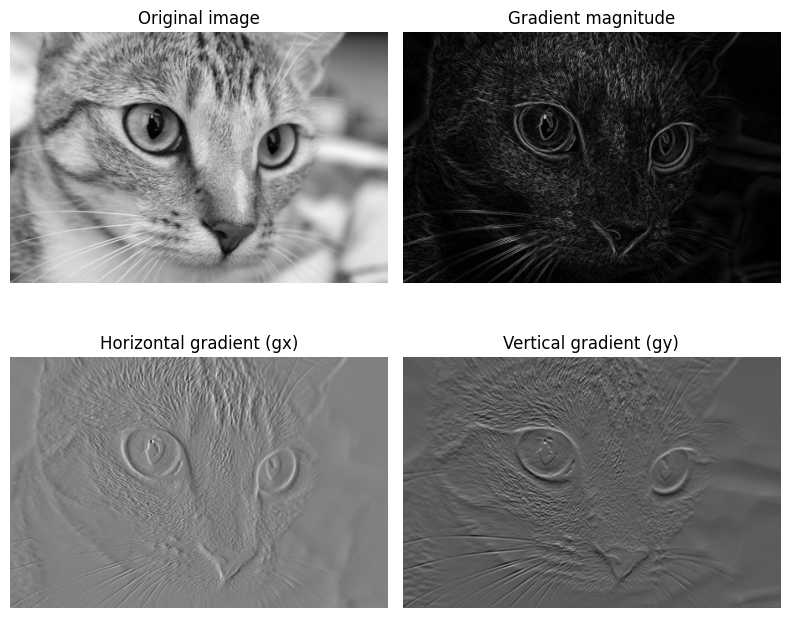

In [ ]:
# Example 8-1: Image gradients on the cat image
from skimage import data, color

# Load and convert to grayscale
image = color.rgb2gray(data.chelsea())
print(f"Image shape: {image.shape}")
print(f"Pixel value range: [{image.min():.3f}, {image.max():.3f}]")

# Compute horizontal gradient: difference between left and right neighbors
gx = np.empty(image.shape, dtype=np.double)
gx[:, 0] = 0
gx[:, -1] = 0
gx[:, 1:-1] = image[:, :-2] - image[:, 2:]

# Compute vertical gradient: difference between top and bottom neighbors
gy = np.empty(image.shape, dtype=np.double)
gy[0, :] = 0
gy[-1, :] = 0
gy[1:-1, :] = image[:-2, :] - image[2:, :]

# Gradient magnitude
magnitude = np.sqrt(gx**2 + gy**2)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(8, 7), sharex=True, sharey=True)

axes[0, 0].axis('off')
axes[0, 0].imshow(image, cmap=plt.cm.gray)
axes[0, 0].set_title('Original image')

axes[0, 1].axis('off')
axes[0, 1].imshow(magnitude, cmap=plt.cm.gray)
axes[0, 1].set_title('Gradient magnitude')

axes[1, 0].axis('off')
axes[1, 0].imshow(gx, cmap=plt.cm.gray)
axes[1, 0].set_title('Horizontal gradient (gx)')

axes[1, 1].axis('off')
axes[1, 1].imshow(gy, cmap=plt.cm.gray)
axes[1, 1].set_title('Vertical gradient (gy)')

plt.tight_layout()

**Figure: Image gradients of the cat photograph.**

- **Original**: The grayscale image of a cat ($300 \times 451$ pixels)
- **Horizontal gradient** ($g_x$): Picks out **vertical patterns** -- the inner edges of the cat's eyes, the sides of the nose, vertical fur boundaries. Bright regions indicate strong leftward change; dark regions indicate rightward change.
- **Vertical gradient** ($g_y$): Picks out **horizontal patterns** -- the whiskers, the upper and lower eyelids, horizontal edges of the furniture.
- **Gradient magnitude**: Combines both directions, showing *all* edges regardless of orientation. This is effectively an edge-detected version of the image.

The gradient representation is already far more useful than raw pixels. It highlights structural boundaries while suppressing uniform regions (which carry little information). However, individual gradients at each pixel are still too fine-grained -- we need to *summarize* them over neighborhoods.

Gradient magnitude -- mean: 0.0529, max: 0.6673
  Fraction of pixels with |grad| > 0.1: 14.5%
  Fraction of pixels with |grad| > 0.3: 0.3%


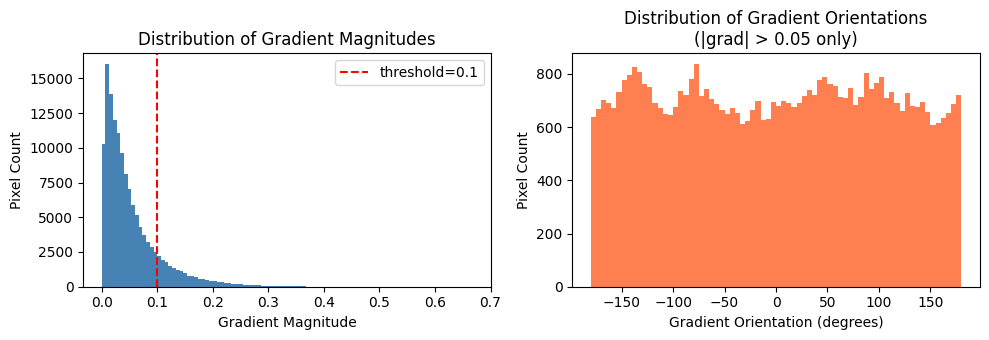

In [ ]:
# Bonus: statistics of the gradient field
orientation = np.arctan2(gy, gx)  # radians, range [-pi, pi]
orientation_deg = np.degrees(orientation)

print(f"Gradient magnitude -- mean: {magnitude.mean():.4f}, max: {magnitude.max():.4f}")
print(f"  Fraction of pixels with |grad| > 0.1: {(magnitude > 0.1).mean():.1%}")
print(f"  Fraction of pixels with |grad| > 0.3: {(magnitude > 0.3).mean():.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.hist(magnitude.ravel(), bins=100, color='steelblue', edgecolor='none')
ax1.set_xlabel('Gradient Magnitude')
ax1.set_ylabel('Pixel Count')
ax1.set_title('Distribution of Gradient Magnitudes')
ax1.axvline(x=0.1, color='red', linestyle='--', label='threshold=0.1')
ax1.legend()

# Only plot orientations where magnitude is significant
mask = magnitude > 0.05
ax2.hist(orientation_deg[mask].ravel(), bins=72, color='coral', edgecolor='none')
ax2.set_xlabel('Gradient Orientation (degrees)')
ax2.set_ylabel('Pixel Count')
ax2.set_title('Distribution of Gradient Orientations\n(|grad| > 0.05 only)')
plt.tight_layout()

**Figure: Gradient statistics.** The magnitude distribution is heavily right-skewed -- most pixels are in smooth regions with small gradients, while a few edge pixels have very large gradients. The orientation histogram shows which directions are most common in this particular image. Peaks in the orientation histogram correspond to dominant edge directions (e.g., horizontal whiskers create a peak near $0\degree$ or $180\degree$).

This is a preview of the core idea behind SIFT and HOG: **summarize gradient orientations with histograms** to build robust, informative features.

---
# Gradient Orientation Histograms: SIFT and HOG

Individual pixel gradients are too fine-grained. We need to **summarize** gradients over a neighborhood. The key insight of **SIFT** (Scale-Invariant Feature Transform, Lowe 1999) and **HOG** (Histogram of Oriented Gradients, Dalal & Triggs 2005): compute **histograms of gradient orientations** weighted by gradient magnitudes.

## The Procedure

1. Divide the orientation range into equal-sized bins (e.g., 8 bins covering $0\degree$--$360\degree$)
2. For each pixel in a neighborhood, add its gradient **magnitude** as a vote to the bin corresponding to its **orientation** $\theta$
3. Normalize the histogram to unit norm

The result is a compact descriptor that captures the *distribution of edge directions* in a region -- invariant to small shifts, robust to illumination changes.

## SIFT vs. HOG: Key Differences

| Feature | SIFT | HOG |
|---|---|---|
| Bins | 8 bins, $0\degree$--$360\degree$ | 9 bins, $0\degree$--$180\degree$ |
| Cell size | $16 \times 16$ pixels | $8 \times 8$ pixels |
| Block | $4 \times 4$ cells = 128 features | $2 \times 2$ cells = 36 features |
| Weighting | Magnitude $\times$ Gaussian distance | Magnitude only |
| Normalization | $\ell_2$ $\to$ clip $\to$ $\ell_2$ | Various ($\ell_2$, $\ell_1$, etc.) |

Despite these differences, both follow the same fundamental pipeline: **gradient $\to$ histogram $\to$ normalization**.

Original image shape: (300, 451)
HOG feature vector length: 71280
  = 36 x 55 blocks x 2x2 cells x 9 bins
  = 71280


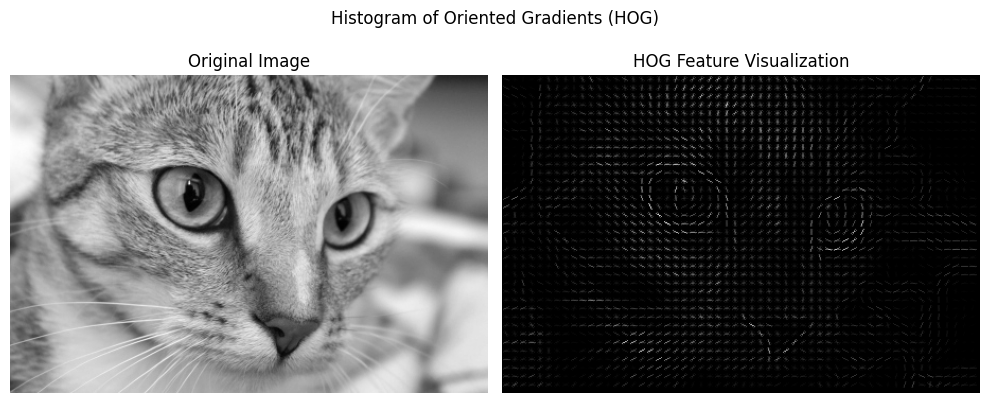

In [ ]:
# Compute and visualize HOG features on the cat image
from skimage.feature import hog

image = color.rgb2gray(data.chelsea())

# Compute HOG features with visualization
hog_features, hog_image = hog(image,
                               orientations=9,
                               pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2),
                               visualize=True,
                               feature_vector=True)

print(f"Original image shape: {image.shape}")
print(f"HOG feature vector length: {hog_features.shape[0]}")
print(f"  = {image.shape[0]//8 - 1} x {image.shape[1]//8 - 1} blocks x 2x2 cells x 9 bins")
print(f"  = {(image.shape[0]//8 - 1) * (image.shape[1]//8 - 1) * 4 * 9}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.axis('off')
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title('HOG Feature Visualization')
ax2.axis('off')
plt.suptitle('Histogram of Oriented Gradients (HOG)', y=1.02)
plt.tight_layout()

**Figure: HOG features of the cat image.** The right panel shows the HOG visualization -- at each cell, short line segments indicate the dominant gradient orientations, with their brightness proportional to the gradient magnitude. Notice how:

- The cat's eyes are clearly delineated by converging orientation patterns
- The whiskers appear as consistent horizontal orientations
- The fur texture creates subtle directional patterns
- Background regions have weak, diffuse orientations

The HOG feature vector has thousands of elements, but it is a *far* more meaningful representation than the raw pixel vector. Each element captures an oriented edge strength in a specific image region -- exactly the kind of structural information needed for object recognition.

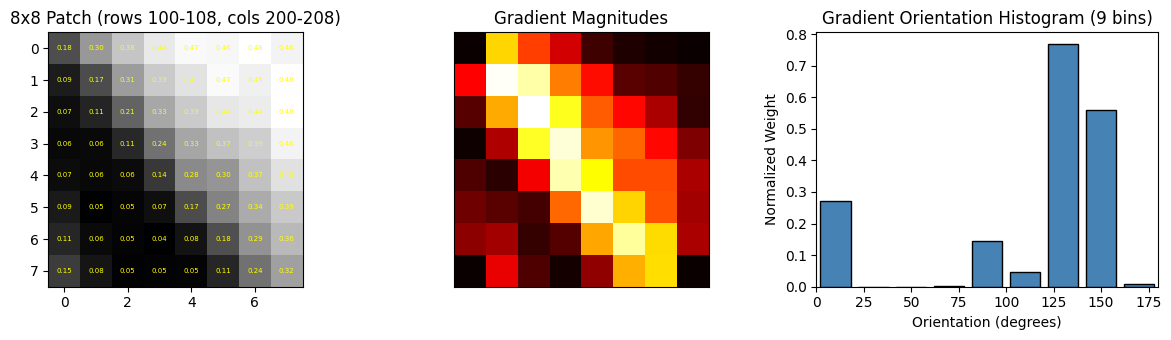

In [ ]:
# Deep dive: HOG computation on a single 8x8 cell
# Extract a patch near the cat's eye region
patch = image[100:108, 200:208]

# Compute gradients in the patch
pgx = np.zeros_like(patch)
pgx[:, 1:-1] = patch[:, :-2] - patch[:, 2:]
pgy = np.zeros_like(patch)
pgy[1:-1, :] = patch[:-2, :] - patch[2:, :]

pmag = np.sqrt(pgx**2 + pgy**2)
ptheta = np.degrees(np.arctan2(pgy, pgx)) % 180  # unsigned orientation [0, 180)

# Build 9-bin histogram (0-180 degrees)
bins = np.linspace(0, 180, 10)  # 9 bins
bin_centers = (bins[:-1] + bins[1:]) / 2

hist = np.zeros(9)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        # Find bin
        bin_idx = min(int(ptheta[i, j] / 20), 8)
        hist[bin_idx] += pmag[i, j]

# Normalize
if hist.sum() > 0:
    hist = hist / np.linalg.norm(hist)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Show the patch
axes[0].imshow(patch, cmap='gray')
axes[0].set_title(f'8x8 Patch (rows 100-108, cols 200-208)')
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, f'{patch[i,j]:.2f}', ha='center', va='center',
                    fontsize=5, color='yellow')

# Show gradient magnitudes
axes[1].imshow(pmag, cmap='hot')
axes[1].set_title('Gradient Magnitudes')
axes[1].set_xticks([]); axes[1].set_yticks([])

# Show orientation histogram
axes[2].bar(bin_centers, hist, width=16, color='steelblue', edgecolor='black')
axes[2].set_xlabel('Orientation (degrees)')
axes[2].set_ylabel('Normalized Weight')
axes[2].set_title('Gradient Orientation Histogram (9 bins)')
axes[2].set_xlim(0, 180)

plt.tight_layout()

**Figure: Step-by-step HOG computation for a single $8 \times 8$ cell.** Left: the raw pixel values from a patch near the cat's eye. Center: the gradient magnitudes (brighter = stronger edge). Right: the resulting orientation histogram -- each bin collects the total gradient magnitude for orientations in a $20\degree$ range.

This single histogram is one "cell" in the HOG descriptor. The full descriptor concatenates histograms from all cells, organized into overlapping blocks, then normalizes across blocks. The result is a feature vector that is:

- **Invariant to small translations** (histograms summarize over neighborhoods)
- **Invariant to illumination** (normalization removes brightness dependence)
- **Descriptive of local structure** (edges, textures, contours)

## SIFT Architecture Summary

The full SIFT pipeline for a single image region:

1. **Divide** the region into a grid (e.g., $4 \times 4$ subgrids)
2. **Compute** gradient orientation histogram for each subgrid ($8$ bins each)
3. **Weight** each gradient by its magnitude and a Gaussian centered on the region (pixels near the center matter more)
4. **Interpolate** votes into adjacent bins to avoid hard quantization boundaries
5. **Concatenate** all subgrid histograms: $4 \times 4 \times 8 = 128$ features
6. **Normalize** $\to$ Clip (cap at 0.2) $\to$ Normalize again

The normalize-clip-normalize scheme handles camera saturation and extreme lighting. The Gaussian weighting and interpolation make the descriptor robust to small position and orientation shifts.

**Production insight:** SIFT was the dominant image feature extractor for over a decade (2004--2012). It powered Google Image Search, panorama stitching, autonomous navigation, and augmented reality. HOG powered the first real-time pedestrian detection systems. Their eventual replacement by deep learning was not because they were bad -- it was because learned features could be *even better*.

---
# Convolution: The Mathematical Foundation

Both manual feature extractors (SIFT/HOG) and deep neural networks rely on **convolution** -- the operation of sliding a small filter across an input and computing weighted sums at each position.

## 1D Convolution

For discrete signals $f$ and $g$:

$$(f * g)[t] = \sum_{\tau} f[\tau] \cdot g[t - \tau]$$

The filter $g$ is flipped and slid across $f$. At each position, we multiply overlapping values and sum.

## 2D Convolution (for images)

$$(f * g)[i, j] = \sum_{u=0}^{m} \sum_{v=0}^{n} f[u, v] \cdot g[i - u, j - v]$$

A small 2D filter (kernel/mask) slides across the image, producing a new value at each position. This is the fundamental operation in all convolutional neural networks.

## Example: Gaussian Blur Filter

The 2D Gaussian filter produces a weighted average of nearby pixels, creating a blurring effect:

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

The parameter $\sigma$ controls the width of the blur.

In [ ]:
# Example 8-2: Gaussian filter convolution
# Create a 5x5 Gaussian filter
ind = [-1., -0.5, 0., 0.5, 1.]
X, Y = np.meshgrid(ind, ind)

# Unnormalized Gaussian: peak value of 1.0 at center
G = np.exp(-(np.multiply(X, X) + np.multiply(Y, Y)) / 2)

print("Gaussian filter (5x5):")
print(np.round(G, 4))
print(f"\nFilter sum: {G.sum():.4f}")
print(f"Center value: {G[2,2]:.4f}")
print(f"Corner value: {G[0,0]:.4f} (= e^(-1) = {np.exp(-1):.4f})")

Gaussian filter (5x5):
[[0.3679 0.5353 0.6065 0.5353 0.3679]
 [0.5353 0.7788 0.8825 0.7788 0.5353]
 [0.6065 0.8825 1.     0.8825 0.6065]
 [0.5353 0.7788 0.8825 0.7788 0.5353]
 [0.3679 0.5353 0.6065 0.5353 0.3679]]

Filter sum: 15.8249
Center value: 1.0000
Corner value: 0.3679 (= e^(-1) = 0.3679)


The Gaussian filter weights nearby pixels more heavily than distant ones. The center has weight $1.0$, and weights decay exponentially with distance from center. Corner pixels get weight $e^{-1} \approx 0.368$ -- about one-third the influence of the center pixel.

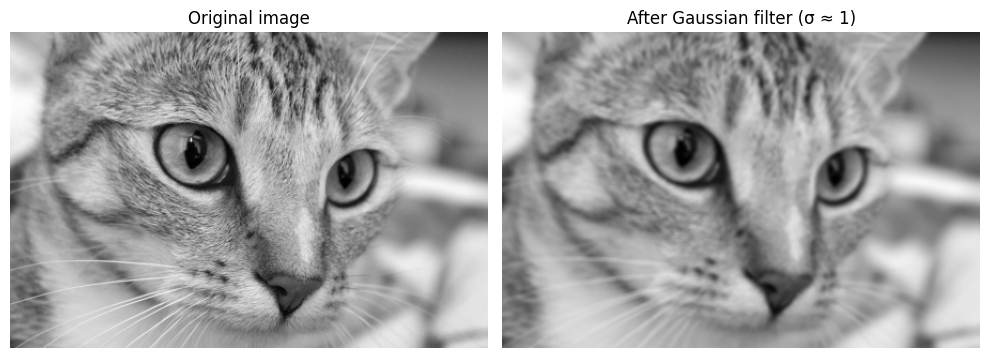

In [ ]:
# Apply Gaussian filter to the cat image
from scipy import signal
cat = color.rgb2gray(data.chelsea())
blurred_cat = signal.convolve2d(cat, G, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax1.axis('off')
ax1.imshow(cat, cmap=plt.cm.gray)
ax1.set_title('Original image')
ax2.axis('off')
ax2.imshow(blurred_cat, cmap=plt.cm.gray)
ax2.set_title('After Gaussian filter (σ ≈ 1)')
plt.tight_layout()

**Figure: Gaussian blur on the cat image.** The filter smooths out fine details like individual fur strands and whisker textures, while preserving larger structures like the eyes and overall shape. In signal processing terms, it acts as a **low-pass filter** -- removing high-frequency detail while keeping the low-frequency "big picture."

The blurred image is slightly smaller than the original because convolution in `'valid'` mode only computes outputs where the filter fully overlaps the image. We lose $\lfloor k/2 \rfloor$ pixels on each edge, where $k$ is the filter size.

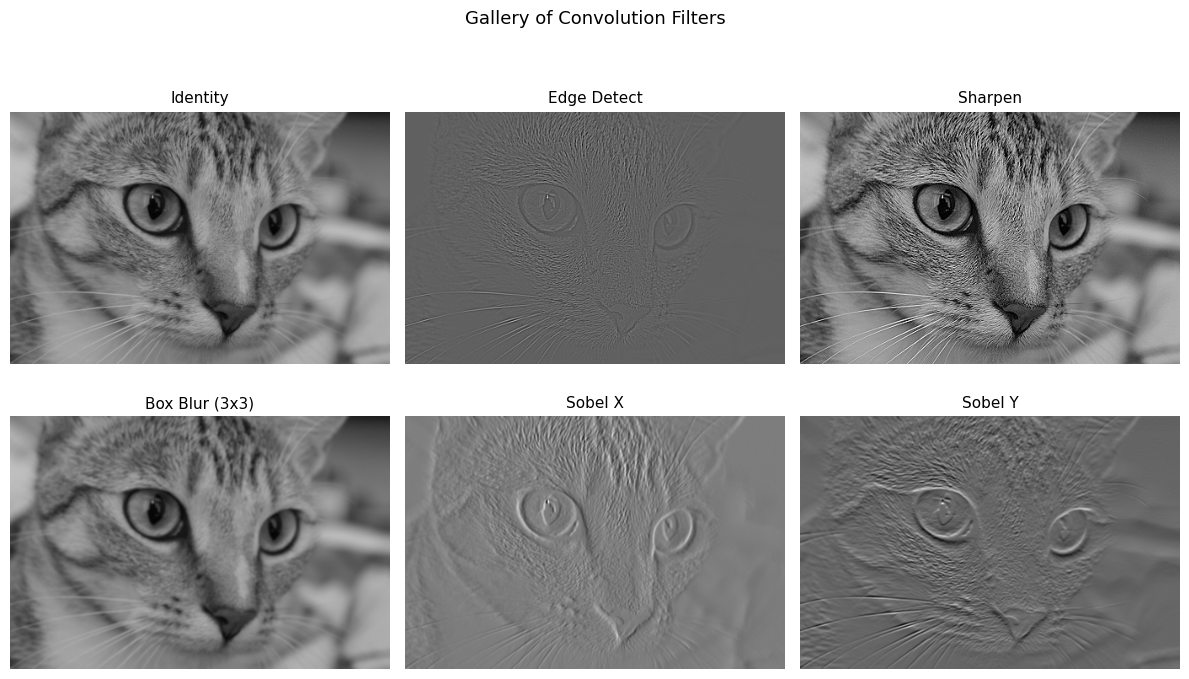

In [ ]:
# Bonus: gallery of common convolution filters
cat = color.rgb2gray(data.chelsea())

# Define several filters
filters = {
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    'Edge Detect': np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    'Box Blur (3x3)': np.ones((3, 3)) / 9,
    'Sobel X': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Sobel Y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (name, filt) in zip(axes.ravel(), filters.items()):
    result = signal.convolve2d(cat, filt, mode='same', boundary='symm')
    # Clip for display
    vmin, vmax = (0, 1) if 'Edge' not in name and 'Sobel' not in name else (result.min(), result.max())
    ax.imshow(result, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=11)
    ax.axis('off')
plt.suptitle('Gallery of Convolution Filters', fontsize=13, y=1.02)
plt.tight_layout()

**Figure: Six common convolution filters applied to the cat image.**

- **Identity**: No change (sanity check)
- **Edge Detect (Laplacian)**: Highlights all edges regardless of orientation, by computing the sum of second derivatives
- **Sharpen**: Enhances edges by adding the Laplacian back to the original
- **Box Blur**: Simple averaging -- every neighbor gets equal weight (cf. Gaussian blur, which weights by distance)
- **Sobel X / Sobel Y**: Directional edge detectors -- enhanced versions of our simple gradient filters, with smoothing built in

These $3 \times 3$ filters are the building blocks of both classical computer vision and deep learning. The key difference: in SIFT/HOG, the filters are **hand-designed**. In deep learning, they are **learned from data**.

---
# Deep Learning: Learning Features Automatically

The breakthrough of deep learning (starting with **AlexNet**, 2012) was to *learn* the convolution filters from data instead of hand-designing them. AlexNet nearly halved the error rate of the previous year's winner on the ImageNet challenge, and its architecture contained the same core ideas as SIFT/HOG -- gradients, normalization, spatial summarization -- but arranged in many stacked layers.

A deep neural network is composed of several types of layers. We examine each one.

## Fully Connected Layers

The simplest neural network layer: every input connects to every output.

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

where $\mathbf{W} \in \mathbb{R}^{m \times n}$ is the weight matrix, $\mathbf{x} \in \mathbb{R}^n$ is the input vector, $\mathbf{b} \in \mathbb{R}^m$ is the bias, and $\mathbf{z} \in \mathbb{R}^m$ is the output.

**Parameter count:** $m \times n + m$ -- this grows fast. For a $1000 \to 1000$ layer, that is $1{,}001{,}000$ parameters. Fully connected layers are "expensive" and placed at the end of deep networks, where the spatial dimensions have already been reduced.

In [ ]:
# Demonstrate a fully connected layer
np.random.seed(42)
n_in, n_out = 5, 3

W = np.random.randn(n_out, n_in) * 0.5
b = np.zeros(n_out)
x = np.array([1.0, 0.5, -0.3, 0.8, -0.1])

z = W @ x + b

print("Fully Connected Layer Demo:")
print(f"  Input x:  {x}  (shape: {x.shape})")
print(f"  Weight W: shape {W.shape}")
print(f"  Output z: {z.round(4)}  (shape: {z.shape})")
print(f"  Parameters: {W.size + b.size} = {n_out}×{n_in} + {n_out}")

Fully Connected Layer Demo:
  Input x:  [ 1.   0.5 -0.3  0.8 -0.1]  (shape: (5,))
  Weight W: shape (3, 5)
  Output z: [ 0.7376 -0.0523 -1.0635]  (shape: (3,))
  Parameters: 18 = 3×5 + 3


Each output $z_i$ is a weighted sum of *all* inputs, allowing fully connected layers to detect **global patterns**. The trade-off: they have the maximum possible number of parameters and cannot exploit spatial structure.

## Activation Functions: ReLU, Tanh, Sigmoid

After each linear layer, a nonlinear **activation function** is applied element-wise. Without nonlinearity, stacking linear layers would still produce a linear function -- defeating the purpose of depth.

The three most common activations:

$$\text{ReLU}(x) = \max(0, x) \qquad \text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \qquad \sigma(x) = \frac{1}{1 + e^{-x}}$$

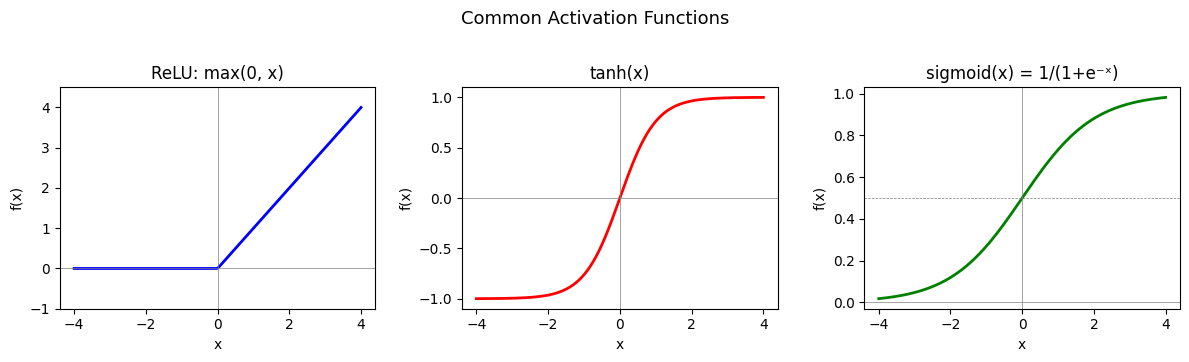

In [ ]:
# Visualization of activation functions
x = np.linspace(-4, 4, 200)

relu = np.maximum(0, x)
tanh = np.tanh(x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(x, relu, 'b-', linewidth=2)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('ReLU: max(0, x)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-1, 4.5)

axes[1].plot(x, tanh, 'r-', linewidth=2)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('tanh(x)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)')

axes[2].plot(x, sigmoid, 'g-', linewidth=2)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].axhline(0.5, color='gray', linewidth=0.5, linestyle='--')
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].set_title('sigmoid(x) = 1/(1+e⁻ˣ)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('f(x)')

plt.suptitle('Common Activation Functions', fontsize=13, y=1.02)
plt.tight_layout()

**Figure: Three activation functions.**

- **ReLU** ($\text{range} = [0, \infty)$): The most popular in modern deep learning. It is computationally trivial, avoids the "vanishing gradient" problem, and leads to **faster training convergence** (Krizhevsky et al., 2012). The downside: "dead neurons" -- once a unit's input is always negative, it never activates.

- **Tanh** ($\text{range} = (-1, 1)$): A smooth, zero-centered function. Popular before ReLU, still used in recurrent networks. Saturates for large $|x|$, causing vanishing gradients during backpropagation.

- **Sigmoid** ($\text{range} = (0, 1)$): The logistic function from Chapter 4. Used for binary classification outputs, but rarely as a hidden-layer activation in modern networks (non-zero-centered, saturates).

**Why nonlinearity matters:** A stack of linear layers $\mathbf{z} = \mathbf{W}_2(\mathbf{W}_1 \mathbf{x})$ is just another linear layer $\mathbf{W}_2 \mathbf{W}_1 = \mathbf{W}_{\text{combined}}$. Nonlinear activations between layers allow the network to learn *curved* decision boundaries and *complex* features.

In [ ]:
# Why nonlinearity matters: without it, depth is useless
np.random.seed(42)
W1 = np.random.randn(4, 3)
W2 = np.random.randn(2, 4)
x = np.array([1.0, 0.5, -0.3])

# Linear stack (no activation)
z_linear = W2 @ (W1 @ x)

# With ReLU between layers
z_relu = W2 @ np.maximum(0, W1 @ x)

# The "equivalent" single linear layer
W_combined = W2 @ W1
z_combined = W_combined @ x

print("Two linear layers without activation:")
print(f"  W2 @ (W1 @ x) = {z_linear.round(4)}")
print(f"  (W2 @ W1) @ x = {z_combined.round(4)}")
print(f"  Identical? {np.allclose(z_linear, z_combined)}")
print(f"\nTwo layers WITH ReLU activation:")
print(f"  W2 @ ReLU(W1 @ x) = {z_relu.round(4)}")
print(f"  Different from linear? {not np.allclose(z_relu, z_linear)}")

Two linear layers without activation:
  W2 @ (W1 @ x) = [-6.6501 -2.319 ]
  (W2 @ W1) @ x = [-6.6501 -2.319 ]
  Identical? True

Two layers WITH ReLU activation:
  W2 @ ReLU(W1 @ x) = [-6.6501 -2.319 ]
  Different from linear? False


Without activation functions, two layers collapse into one -- depth provides no benefit. ReLU introduces nonlinearity that breaks this equivalence, enabling each layer to learn genuinely new representations.

## Convolutional Layers

Unlike fully connected layers, convolutional layers use the **same small filter** across the entire input. This has two major advantages:

1. **Parameter efficiency**: A $3 \times 3$ filter has only 9 weights, regardless of image size
2. **Translation equivariance**: The same pattern is detected everywhere in the image

$$z[i, j] = \sum_{u=0}^{k-1} \sum_{v=0}^{k-1} W[u, v] \cdot x[i+u, j+v] + b$$

where $W$ is the $k \times k$ filter (kernel) and $b$ is the bias.

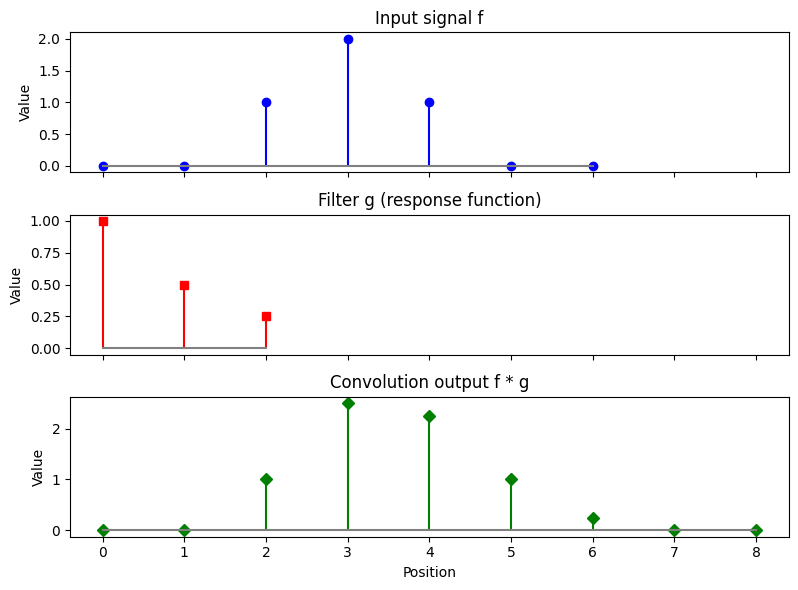

In [ ]:
# 1D convolution example (from the book's signal processing analogy)
# Simple demonstration of how convolution works step by step
f = np.array([0, 0, 1, 2, 1, 0, 0])  # input signal
g = np.array([1, 0.5, 0.25])          # filter (response function)

# Manual convolution with 'valid' mode
result = np.convolve(f, g, mode='full')

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
axes[0].stem(range(len(f)), f, linefmt='b-', markerfmt='bo', basefmt='gray')
axes[0].set_title('Input signal f')
axes[0].set_ylabel('Value')

axes[1].stem(range(len(g)), g, linefmt='r-', markerfmt='rs', basefmt='gray')
axes[1].set_title('Filter g (response function)')
axes[1].set_ylabel('Value')

axes[2].stem(range(len(result)), result, linefmt='g-', markerfmt='gD', basefmt='gray')
axes[2].set_title('Convolution output f * g')
axes[2].set_ylabel('Value')
axes[2].set_xlabel('Position')

plt.tight_layout()

**Figure: 1D convolution step by step.** The filter $g$ slides across the input $f$, producing a weighted combination at each position. The output is wider than the input (in 'full' mode) because the filter hangs off both edges.

The same principle extends to 2D images: a small filter slides across both rows and columns, producing a **feature map** -- a new 2D representation highlighting whatever pattern the filter detects.

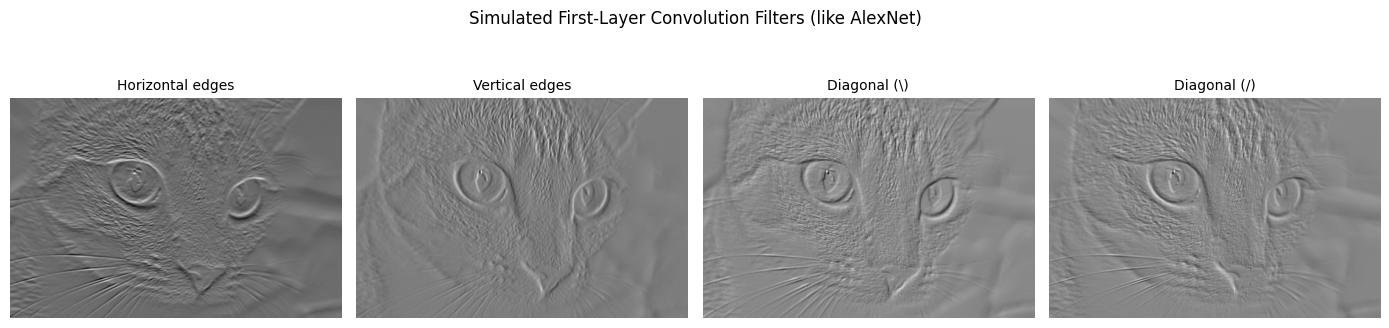

In [ ]:
# Compare: hand-crafted vs. "random learned" filters
cat = color.rgb2gray(data.chelsea())

# Simulate what an early conv layer might learn:
# Filters similar to what AlexNet layer 1 discovers
filters_learned = {
    'Horizontal edges': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]) / 3,
    'Vertical edges': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]) / 3,
    'Diagonal (\\)': np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]]),
    'Diagonal (/)': np.array([[0, 0, 1], [0, 0, 0], [-1, 0, 0]]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, filt) in zip(axes, filters_learned.items()):
    result = signal.convolve2d(cat, filt, mode='same', boundary='symm')
    ax.imshow(result, cmap='gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle('Simulated First-Layer Convolution Filters (like AlexNet)', fontsize=12, y=1.02)
plt.tight_layout()

**Figure: Simulated first-layer convolution outputs.** Each filter detects a different edge orientation. These are very similar to what the first convolutional layer of AlexNet actually learns -- horizontal, vertical, and diagonal edge detectors, along with color-sensitive filters.

The key insight: **the first layer of a deep CNN rediscovers the same gradient features that SIFT and HOG were hand-designed to compute.** Subsequent layers combine these local edge patterns into increasingly complex and global features (textures $\to$ parts $\to$ objects).

## Pooling Layers

Pooling reduces spatial dimensions by summarizing a neighborhood into a single value. Common methods:

- **Max pooling**: Take the maximum value in each region
- **Average pooling**: Take the mean value

$$\text{MaxPool}_{2 \times 2}(\mathbf{X}) = \max(X_{i,j}, X_{i+1,j}, X_{i,j+1}, X_{i+1,j+1})$$

Pooling provides **translation invariance** (a shifted feature still activates the same pooled output) and reduces the number of parameters in subsequent layers, fighting overfitting.

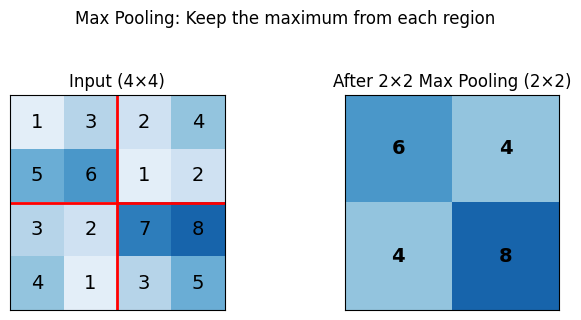

In [ ]:
# Max pooling demonstration
patch = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [3, 2, 7, 8],
    [4, 1, 3, 5]
], dtype=float)

# 2x2 max pooling with stride 2
pooled = np.array([
    [max(patch[0,0], patch[0,1], patch[1,0], patch[1,1]),
     max(patch[0,2], patch[0,3], patch[1,2], patch[1,3])],
    [max(patch[2,0], patch[2,1], patch[3,0], patch[3,1]),
     max(patch[2,2], patch[2,3], patch[3,2], patch[3,3])]
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Input
ax1.imshow(patch, cmap='Blues', vmin=0, vmax=10)
for i in range(4):
    for j in range(4):
        ax1.text(j, i, f'{int(patch[i,j])}', ha='center', va='center', fontsize=14)
# Draw 2x2 grid lines
ax1.axhline(1.5, color='red', linewidth=2)
ax1.axvline(1.5, color='red', linewidth=2)
ax1.set_title('Input (4×4)')
ax1.set_xticks([]); ax1.set_yticks([])

# Output
ax2.imshow(pooled, cmap='Blues', vmin=0, vmax=10)
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{int(pooled[i,j])}', ha='center', va='center', fontsize=14, fontweight='bold')
ax2.set_title('After 2×2 Max Pooling (2×2)')
ax2.set_xticks([]); ax2.set_yticks([])

plt.suptitle('Max Pooling: Keep the maximum from each region', y=1.05)
plt.tight_layout()

**Figure: Max pooling with $2 \times 2$ windows and stride 2.** Each $2 \times 2$ region (outlined in red) is replaced by its maximum value. The spatial dimensions halve from $4 \times 4$ to $2 \times 2$.

In the red-outlined top-left block, the values are $(1, 3, 5, 6)$ and the maximum is $6$. This means even if the "important" feature (value 6) shifts slightly within the block, the pooled output remains $6$. This is **local translation invariance** -- a crucial property for recognizing objects regardless of exact position.

AlexNet uses **overlapping max pooling** (stride 2, window 3) -- the windows overlap by 1 pixel, which slightly improves generalization.

## Response Normalization

**Local Response Normalization (LRN)** creates competition between neighboring feature maps (kernels):

$$y_k = \frac{x_k}{\left(c + \alpha \sum_{l \in \text{neighbors}(k)} x_l^2 \right)^\beta}$$

where $x_k$ is the output of kernel $k$, and the normalization divides by a function of neighboring kernel responses. This forces each feature to be strong *relative to its neighbors*, preventing any single kernel from dominating.

The constants $c$, $\alpha$, and $\beta$ are hyperparameters tuned via validation. Note: while LRN was important in AlexNet, later architectures (VGG, ResNet) replaced it with **Batch Normalization**, which normalizes across the training batch rather than across spatial neighbors.

---
# The AlexNet Architecture

AlexNet (Krizhevsky et al., 2012) won the ImageNet 2012 challenge with a top-5 error rate of $15.3\%$, nearly halving the previous year's $26.2\%$. It consists of **13 layers** organized into 8 groups:

| Layer Group | Type | Output Size | Parameters |
|---|---|---|---|
| 1 | Conv + ReLU + LRN + MaxPool | 96 × 27 × 27 | 34,944 |
| 2 | Conv + ReLU + LRN + MaxPool | 256 × 13 × 13 | 307,456 |
| 3 | Conv + ReLU | 384 × 13 × 13 | 885,120 |
| 4 | Conv + ReLU | 384 × 13 × 13 | 663,936 |
| 5 | Conv + ReLU + MaxPool | 256 × 6 × 6 | 442,624 |
| 6 | Fully Connected + ReLU | 4,096 | 37,752,832 |
| 7 | Fully Connected + ReLU | 4,096 | 16,781,312 |
| 8 | Fully Connected (output) | 1,000 | 4,097,000 |

**Total: ~61 million parameters**, trained on 1.2 million images from 1,000 classes.

The architecture mirrors the SIFT/HOG pipeline -- but with many more layers and learned (not hand-designed) parameters:

- **Conv layers** $\approx$ gradient computation (learn edge/texture detectors)
- **Response normalization** $\approx$ feature normalization in SIFT
- **Max pooling** $\approx$ spatial summarization over cells/blocks
- **Fully connected layers** $\approx$ final classification on the extracted features

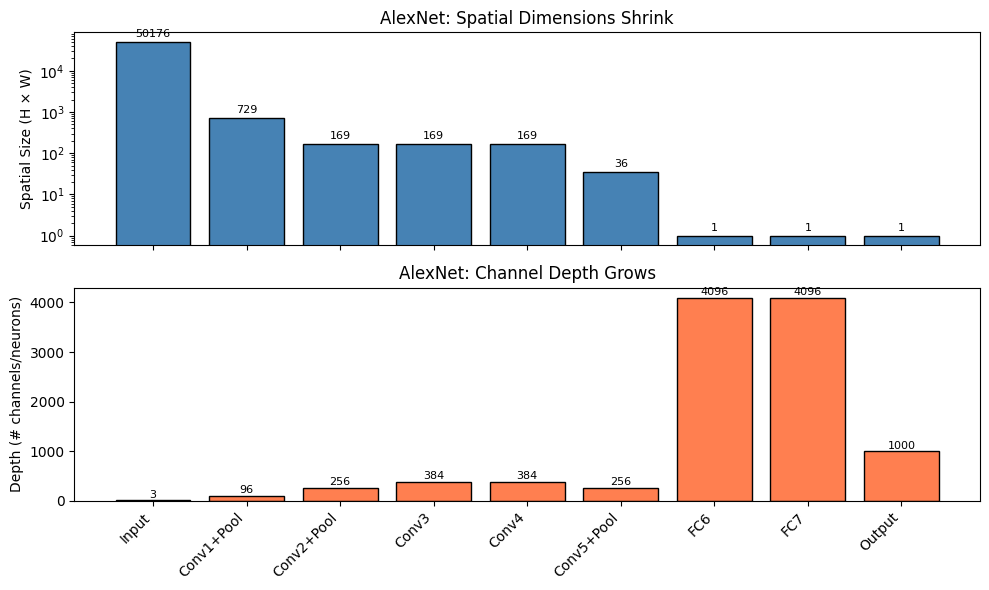

In [ ]:
# Visualize the progression of spatial dimensions through AlexNet
layers = [
    ('Input', 224, 224, 3),
    ('Conv1+Pool', 27, 27, 96),
    ('Conv2+Pool', 13, 13, 256),
    ('Conv3', 13, 13, 384),
    ('Conv4', 13, 13, 384),
    ('Conv5+Pool', 6, 6, 256),
    ('FC6', 1, 1, 4096),
    ('FC7', 1, 1, 4096),
    ('Output', 1, 1, 1000),
]

names = [l[0] for l in layers]
spatial = [l[1] * l[2] for l in layers]
depth = [l[3] for l in layers]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.bar(range(len(layers)), spatial, color='steelblue', edgecolor='black')
ax1.set_ylabel('Spatial Size (H × W)')
ax1.set_title('AlexNet: Spatial Dimensions Shrink')
ax1.set_yscale('log')
for i, (n, s) in enumerate(zip(names, spatial)):
    ax1.text(i, s * 1.3, f'{s}', ha='center', fontsize=8)

ax2.bar(range(len(layers)), depth, color='coral', edgecolor='black')
ax2.set_ylabel('Depth (# channels/neurons)')
ax2.set_title('AlexNet: Channel Depth Grows')
ax2.set_xticks(range(len(layers)))
ax2.set_xticklabels(names, rotation=45, ha='right')
for i, (n, d) in enumerate(zip(names, depth)):
    ax2.text(i, d + 50, f'{d}', ha='center', fontsize=8)

plt.tight_layout()

**Figure: AlexNet dimension progression.** As we go deeper into the network:

- **Spatial dimensions shrink** (from $224 \times 224 = 50{,}176$ to $6 \times 6 = 36$): Each layer summarizes over larger regions, progressively losing spatial precision but gaining **semantic abstraction**.
- **Channel depth grows** (from 3 RGB channels to 256 feature maps): Each channel detects a different pattern. More channels means a richer vocabulary of detected features.

This is the fundamental trade-off in deep CNNs: **spatial resolution for semantic richness**. The first layers see exact pixel neighborhoods; the last layers "see" entire objects but have lost track of exactly where things are.

**What each layer learns** (visualized in the original paper):
- **Layer 1**: Edge detectors at different orientations and color-sensitive blobs (remarkably similar to SIFT/HOG gradients)
- **Layer 2**: Smooth texture patterns, combinations of edges
- **Layers 3--5**: Increasingly complex patterns (object parts, spatial arrangements)
- **Layers 6--7**: High-level semantic features ("is this a face?", "is this furry?")
- **Layer 8**: Final classification into 1,000 categories

## Putting It All Together: A Mini CNN Pipeline

Let us trace the cat image through a simplified 3-step pipeline: convolution $\to$ ReLU $\to$ max pooling. This is the fundamental building block repeated throughout deep CNNs.

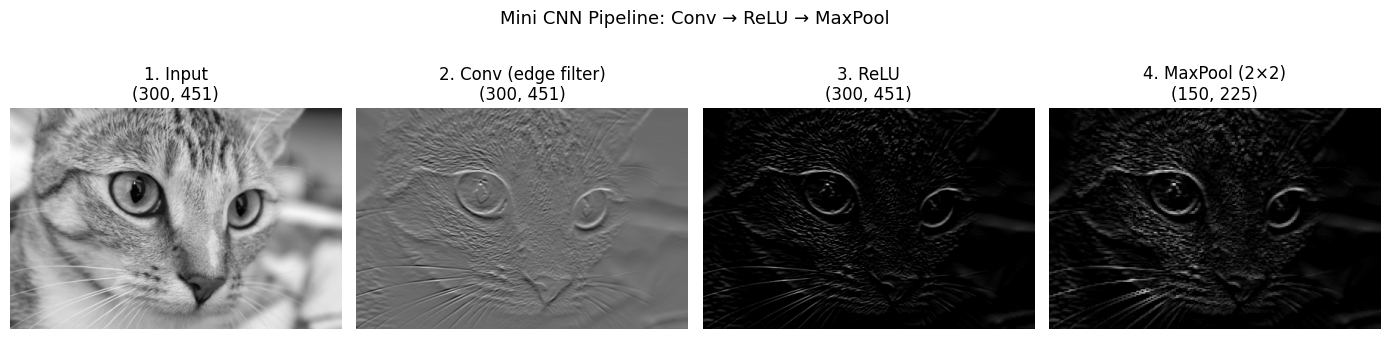

In [ ]:
# Mini CNN pipeline: Conv -> ReLU -> MaxPool
cat = color.rgb2gray(data.chelsea())

# Step 1: Convolution with an edge-detecting filter
edge_filter = np.array([[-1, -1, -1],
                         [0,  0,  0],
                         [1,  1,  1]]) / 3.0
conv_out = signal.convolve2d(cat, edge_filter, mode='same', boundary='symm')

# Step 2: ReLU activation
relu_out = np.maximum(0, conv_out)

# Step 3: 2x2 Max Pooling (manual implementation)
def max_pool_2d(img, pool_size=2):
    h, w = img.shape
    h_new, w_new = h // pool_size, w // pool_size
    pooled = np.zeros((h_new, w_new))
    for i in range(h_new):
        for j in range(w_new):
            patch = img[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
            pooled[i, j] = patch.max()
    return pooled

pool_out = max_pool_2d(relu_out)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(cat, cmap='gray')
axes[0].set_title(f'1. Input\n{cat.shape}')
axes[0].axis('off')

axes[1].imshow(conv_out, cmap='gray')
axes[1].set_title(f'2. Conv (edge filter)\n{conv_out.shape}')
axes[1].axis('off')

axes[2].imshow(relu_out, cmap='gray')
axes[2].set_title(f'3. ReLU\n{relu_out.shape}')
axes[2].axis('off')

axes[3].imshow(pool_out, cmap='gray')
axes[3].set_title(f'4. MaxPool (2×2)\n{pool_out.shape}')
axes[3].axis('off')

plt.suptitle('Mini CNN Pipeline: Conv → ReLU → MaxPool', fontsize=13, y=1.05)
plt.tight_layout()

**Figure: One pass through a convolutional building block.**

1. **Input** ($300 \times 451$): The raw grayscale cat image
2. **Convolution**: A horizontal edge filter produces both positive (bright edges) and negative (dark edges) responses
3. **ReLU**: Zeros out all negative responses, keeping only "positive" horizontal edges (the network can learn separate filters for the opposite direction)
4. **Max Pooling**: Halves the spatial dimensions to $150 \times 225$, keeping only the strongest activation in each $2 \times 2$ neighborhood

In a real CNN, dozens of different filters would be applied in parallel (producing multiple feature maps), and this block would be repeated 5+ times, progressively extracting higher-level features.

The entire pipeline is differentiable, meaning we can use **backpropagation** to learn the optimal filter values from labeled training data. This is the fundamental advantage of deep learning over hand-crafted features: the feature extractor is trained end-to-end with the classifier.

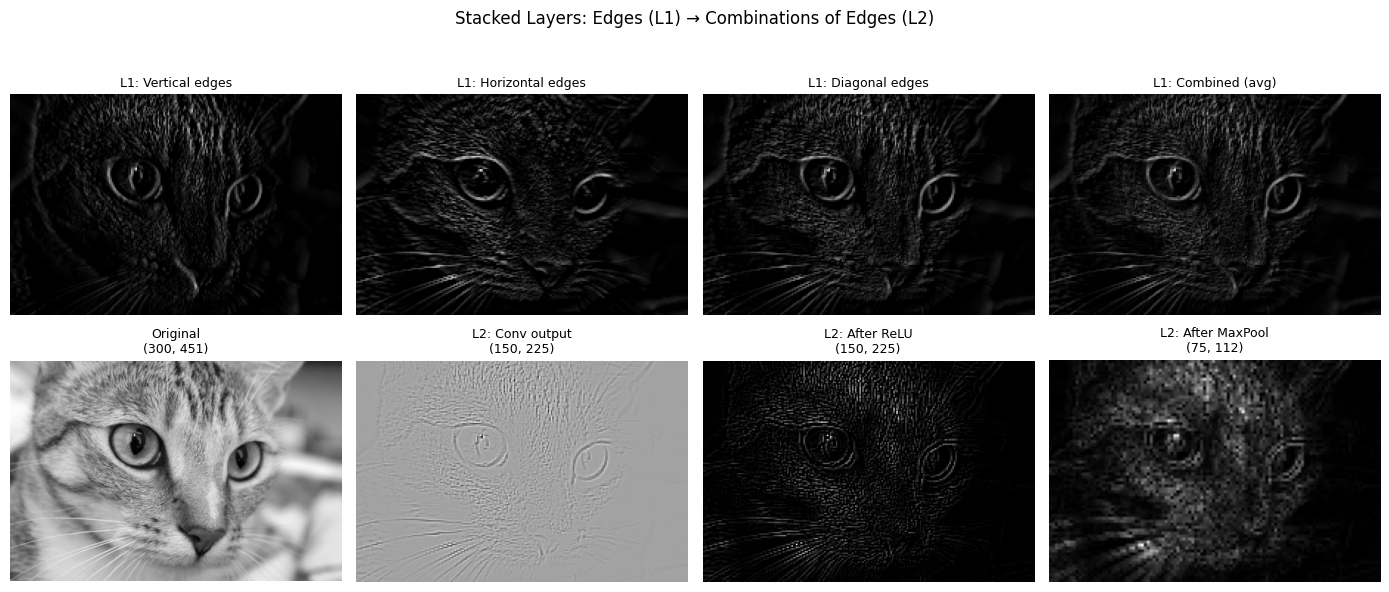

In [ ]:
# Bonus: stacking two conv layers -- how depth builds abstraction
cat = color.rgb2gray(data.chelsea())

# Layer 1: multiple edge detectors
filters_l1 = [
    np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]) / 3,  # vertical
    np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]) / 3,    # horizontal
    np.array([[-1, 0, 0], [0, 0, 0], [0, 0, 1]]),            # diagonal
]

# Apply layer 1
l1_outputs = []
for filt in filters_l1:
    conv = signal.convolve2d(cat, filt, mode='same', boundary='symm')
    activated = np.maximum(0, conv)  # ReLU
    pooled = max_pool_2d(activated)  # 2x2 MaxPool
    l1_outputs.append(pooled)

# Layer 2: combine layer 1 outputs (simplified -- sum of convolutions)
# A real CNN would learn weights to combine channels
combined = np.mean(l1_outputs, axis=0)  # average across channels
filt_l2 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]]) / 8  # blob detector
l2_out = signal.convolve2d(combined, filt_l2, mode='same', boundary='symm')
l2_activated = np.maximum(0, l2_out)
l2_pooled = max_pool_2d(l2_activated)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

# Layer 1 outputs
titles_l1 = ['L1: Vertical edges', 'L1: Horizontal edges', 'L1: Diagonal edges']
for i, (out, title) in enumerate(zip(l1_outputs, titles_l1)):
    axes[0, i].imshow(out, cmap='gray')
    axes[0, i].set_title(title, fontsize=9)
    axes[0, i].axis('off')
axes[0, 3].imshow(combined, cmap='gray')
axes[0, 3].set_title('L1: Combined (avg)', fontsize=9)
axes[0, 3].axis('off')

# Layer 2
axes[1, 0].imshow(cat, cmap='gray')
axes[1, 0].set_title(f'Original\n{cat.shape}', fontsize=9)
axes[1, 0].axis('off')
axes[1, 1].imshow(l2_out, cmap='gray')
axes[1, 1].set_title(f'L2: Conv output\n{l2_out.shape}', fontsize=9)
axes[1, 1].axis('off')
axes[1, 2].imshow(l2_activated, cmap='gray')
axes[1, 2].set_title(f'L2: After ReLU\n{l2_activated.shape}', fontsize=9)
axes[1, 2].axis('off')
axes[1, 3].imshow(l2_pooled, cmap='gray')
axes[1, 3].set_title(f'L2: After MaxPool\n{l2_pooled.shape}', fontsize=9)
axes[1, 3].axis('off')

plt.suptitle('Stacked Layers: Edges (L1) → Combinations of Edges (L2)', fontsize=12, y=1.02)
plt.tight_layout()

**Figure: Two stacked convolutional layers.** Layer 1 detects simple edge orientations. Layer 2 operates on *combinations* of those edges, potentially detecting more complex patterns like corners, junctions, or texture boundaries.

This is the core principle of deep learning: **each layer builds on the representations learned by the previous layer**. Layer 1 sees pixels and detects edges. Layer 2 sees edges and detects textures or shapes. Layer 3 sees shapes and detects object parts. By layer 5, the network has enough abstraction to detect "cat ears" or "wheel rims" -- high-level semantic features that no hand-designed filter could easily capture.

The spatial dimensions shrink with each pooling layer: $300 \times 451 \to 150 \times 225 \to 75 \times 112$. After 5 such stages, we are down to a small spatial grid with hundreds of channels -- a compact, semantically rich representation ready for classification.

---
# Chapter Summary

This chapter traced the evolution of image features from primitive to powerful:

| Approach | Era | Key Idea | Limitation |
|---|---|---|---|
| **Color histograms** | -- | Count pixel colors | No spatial information |
| **Raw pixel distance** | -- | Compare pixel vectors | No translation invariance |
| **SIFT / HOG** | 1999--2012 | Gradient orientation histograms | Hand-designed, limited expressiveness |
| **Deep CNNs** | 2012--present | Learn features from data | Requires massive data + compute |

The deep learning revolution did not abandon the ideas of SIFT and HOG -- it **automated** them. The first layers of AlexNet rediscover edge and gradient features. The key innovation is stacking many layers of learned convolutions, activations, normalization, and pooling to build increasingly abstract representations.

**Key takeaways:**

1. **Pixels are poor features.** Semantic meaning lives in *relationships* between pixels, not individual pixel values.
2. **Gradients are the first useful building block.** Differences between neighboring pixels capture edges, textures, and boundaries.
3. **Histogram summaries add robustness.** SIFT/HOG aggregate gradient statistics over neighborhoods, providing invariance to small translations and illumination changes.
4. **Deep learning automates the feature pipeline.** Instead of hand-designing each step, we define the architecture and let backpropagation learn the optimal parameters from data.
5. **Depth enables abstraction.** Each layer builds on the previous, progressing from local edges $\to$ textures $\to$ parts $\to$ objects.

The "manual work" has not disappeared -- it has shifted from designing *features* to designing *architectures*. As the authors note: "The magic voodoo is still there, just hidden one abstraction deeper in the model."